# A Vanilla GAN on MNIST

Two networks, trained against each other:

* The **generator** $G$ maps a random noise vector $z \sim \mathcal{N}(0, I)$ to a
  fake image. It never sees a real digit.
* The **discriminator** $D$ takes an image and outputs the probability it is *real*.

They play a minimax game
$D$ tries to tell real from fake, $G$ tries to fool $D$:

$$\min_G \max_D \; \mathbb{E}_{x \sim p_\text{data}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log (1 - D(G(z)))]$$

Shape is familiar to Unit 4: stacked
`Linear + activation` layers. The novelty is the **training loop**

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


## 1. Data

The key line is `Normalize((0.5,), (0.5,))`: it maps `[0, 1]` pixels to `[-1, 1]` via
`(x - 0.5) / 0.5`. This matches the generator's `tanh` output so real and fake images
share the same range.

In [9]:
BATCH = 128

tf = transforms.Compose([
    transforms.ToTensor(),                 # [0, 1]
    transforms.Normalize((0.5,), (0.5,)),  # -> [-1, 1]
])
train_dataset = datasets.MNIST(root="./data/", train=True, download=True, transform=tf)
train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True, drop_last=True)
print(f"Images: {len(train_dataset)}, batches/epoch: {len(train_loader)}")

Images: 60000, batches/epoch: 468


## 2. Models

Both networks are plain fully-connected stacks.

**Generator** `z_dim -> 256 -> 512 -> 1024 -> 784`, then `tanh` and reshape to
`1x28x28`. `LeakyReLU` keeps a gradient for negative inputs.

**Discriminator** `784 -> 512 -> 256 -> 1`, then `sigmoid` to a real/fake probability.
`Dropout` stops it from overpowering the generator too early.

In [10]:
Z_DIM = 64
IMG_DIM = 28 * 28

class Generator(nn.Module):
    def __init__(self, z_dim=Z_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),  nn.BatchNorm1d(256),  nn.LeakyReLU(0.2),
            nn.Linear(256, 512),    nn.BatchNorm1d(512),  nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),   nn.BatchNorm1d(1024), nn.LeakyReLU(0.2),
            nn.Linear(1024, IMG_DIM),
            nn.Tanh(),                          # -> [-1, 1]
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(IMG_DIM, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(512, 256),     nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid(),                       # -> P(real)
        )

    def forward(self, x):
        return self.net(x)


G = Generator().to(device)
D = Discriminator().to(device)
print(G)
print(D)
print(f"\nGenerator params: {sum(p.numel() for p in G.parameters()):,}")
print(f"Discriminator params: {sum(p.numel() for p in D.parameters()):,}")

Generator(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Linear(in_features=256, out_features=512, bias=True)
    (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=512, out_features=1024, bias=True)
    (7): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2)
    (9): Linear(in_features=1024, out_features=784, bias=True)
    (10): Tanh()
  )
)
Discriminator(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): LeakyReLU(negative_

## 3. Loss and optimizers

One `BCELoss` serves both networks; only the **target label** changes.

* **Discriminator** — push $D(\text{real}) \to 1$ and $D(\text{fake}) \to 0$.
* **Generator** — push $D(\text{fake}) \to 1$ (we *reuse*
  the "real" label `1` on fake images).

Two separate Adam optimizers, `lr = 2e-4`, `betas = (0.5, 0.999)`

In [11]:
criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

REAL_LABEL, FAKE_LABEL = 1.0, 0.0

## 4. Training

Each step is **two updates**:

1. **Update $D$** — show it a real batch (target `1`) and a fake batch from $G$
   (target `0`); backprop the summed loss. The fake images are `detach()`-ed so this
   step does *not* update $G$.
2. **Update $G$** — generate a fresh fake batch, ask $D$, and train $G$ so $D$ calls
   them real (target `1`).

We hold a **fixed noise batch** aside and decode it every few epochs, so the sample
snapshots show the *same* latent points improving over time.

In [5]:
EPOCHS = 50
fixed_noise = torch.randn(64, Z_DIM, device=device)

history = []        # (d_loss, g_loss, D(real), D(fake))
snapshots = []      # (epoch, 64 generated images)

for epoch in range(1, EPOCHS + 1):
    G.train(); D.train()
    d_run = g_run = dr_run = df_run = 0.0

    for real, _ in train_loader:
        real = real.to(device)
        bs = real.size(0)
        ones  = torch.full((bs, 1), REAL_LABEL, device=device)
        zeros = torch.full((bs, 1), FAKE_LABEL, device=device)

        # --- 1. Discriminator: real -> 1, fake -> 0 ---
        z = torch.randn(bs, Z_DIM, device=device)
        fake = G(z)
        d_real = D(real)
        d_fake = D(fake.detach())          # detach: do not update G here
        loss_D = criterion(d_real, ones) + criterion(d_fake, zeros)
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()

        # --- 2. Generator: fool D, so fake -> 1 ---
        z = torch.randn(bs, Z_DIM, device=device)
        fake = G(z)
        loss_G = criterion(D(fake), ones)  # non-saturating: "real" target on fakes
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()

        d_run  += loss_D.item();         g_run  += loss_G.item()
        dr_run += d_real.mean().item();  df_run += d_fake.mean().item()

    n = len(train_loader)
    history.append((d_run/n, g_run/n, dr_run/n, df_run/n))

    if epoch == 1 or epoch % 5 == 0:
        G.eval()
        with torch.no_grad():
            snapshots.append((epoch, G(fixed_noise).cpu()))
        print(f"epoch {epoch:3d}  loss_D {d_run/n:.3f}  loss_G {g_run/n:.3f}  "
              f"D(real) {dr_run/n:.2f}  D(fake) {df_run/n:.2f}")

torch.save(G.state_dict(), "gan_mnist_generator.pth")
print("\nSaved gan_mnist_generator.pth")

epoch   1  loss_D 1.303  loss_G 0.805  D(real) 0.59  D(fake) 0.52
epoch   5  loss_D 1.249  loss_G 0.954  D(real) 0.57  D(fake) 0.45
epoch  10  loss_D 1.291  loss_G 0.850  D(real) 0.55  D(fake) 0.46
epoch  15  loss_D 1.312  loss_G 0.822  D(real) 0.54  D(fake) 0.47
epoch  20  loss_D 1.330  loss_G 0.800  D(real) 0.53  D(fake) 0.47
epoch  25  loss_D 1.340  loss_G 0.782  D(real) 0.52  D(fake) 0.48
epoch  30  loss_D 1.347  loss_G 0.769  D(real) 0.52  D(fake) 0.48
epoch  35  loss_D 1.353  loss_G 0.763  D(real) 0.52  D(fake) 0.48
epoch  40  loss_D 1.355  loss_G 0.758  D(real) 0.52  D(fake) 0.48
epoch  45  loss_D 1.358  loss_G 0.752  D(real) 0.52  D(fake) 0.49
epoch  50  loss_D 1.361  loss_G 0.746  D(real) 0.51  D(fake) 0.49

Saved gan_mnist_generator.pth


## 5. Reading the loss curves

GAN losses do **not** descend to zero — they are two players in tension, and a
roughly flat, stable pair of curves is the *healthy* sign.

* `D(real)` and `D(fake)` drifting toward **~0.5** — the discriminator can no longer
  tell the difference, i.e. the generator is winning fairly.

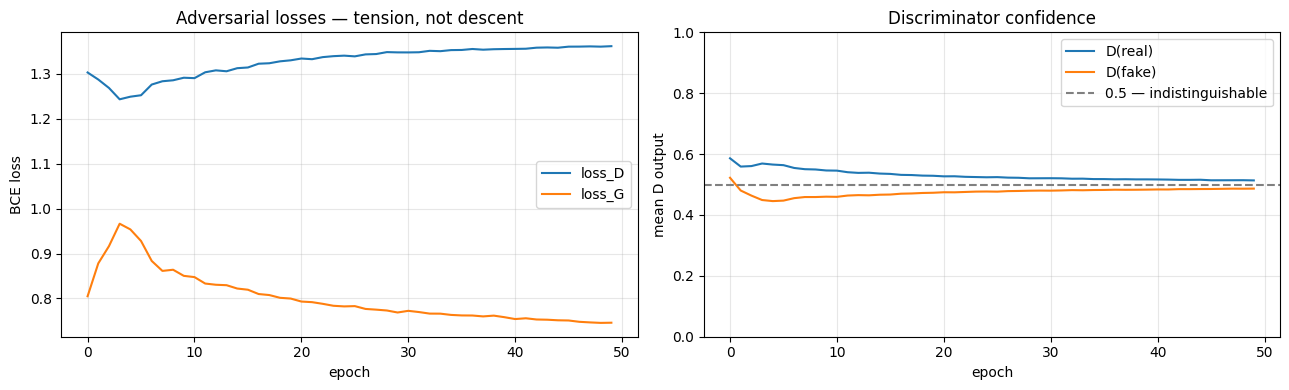

In [6]:
h = np.array(history)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(h[:, 0], label="loss_D")
ax[0].plot(h[:, 1], label="loss_G")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("BCE loss")
ax[0].set_title("Adversarial losses — tension, not descent")
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(h[:, 2], label="D(real)")
ax[1].plot(h[:, 3], label="D(fake)")
ax[1].axhline(0.5, ls="--", c="gray", label="0.5 — indistinguishable")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("mean D output")
ax[1].set_title("Discriminator confidence")
ax[1].set_ylim(0, 1); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Watching the generator learn

The same 64 latent points, decoded at epochs 1, 5, 10, … . Early grids are noise;
structure emerges within a few epochs and sharpens after that.

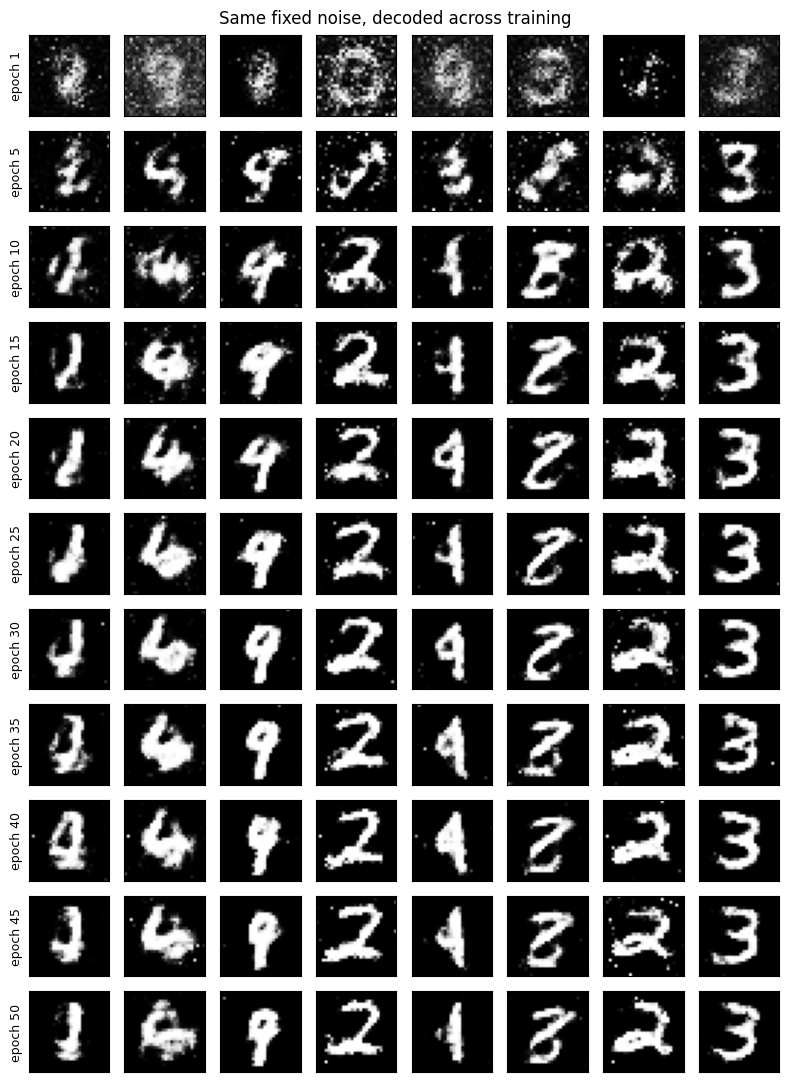

In [7]:
n_snap = len(snapshots)
fig, axes = plt.subplots(n_snap, 8, figsize=(8, n_snap))
for row, (epoch, imgs) in enumerate(snapshots):
    imgs = (imgs + 1) / 2          # [-1, 1] -> [0, 1] for display
    for col in range(8):
        ax = axes[row, col]
        ax.imshow(imgs[col].squeeze(), cmap="gray", vmin=0, vmax=1)
        ax.set_xticks([]); ax.set_yticks([])
    axes[row, 0].set_ylabel(f"epoch {epoch}", fontsize=9)
plt.suptitle("Same fixed noise, decoded across training", fontsize=12)
plt.tight_layout(); plt.show()

## Takeaway

A GAN is different than the AE vs. the autoencoder's reconstruction loss is unique to AE. For GAN we have the *adversarial* one. And a second
network that learns what "looks real" means. No pixel-wise target is ever used.

The cost is a two-player optimization: the loss value alone tells you almost
nothing, so you judge a GAN by **looking at samples**.